In [2]:
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pylab as plt 
import seaborn as sns
import IPython.display as ipd
import hashlib

from scipy.ndimage import maximum_filter
from scipy.ndimage import maximum_filter


from itertools import cycle
from glob import glob 

print('Bibliothèques OK')

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
y, sr = librosa.load("audio2.flac", sr=44100)

NameError: name 'librosa' is not defined

<Axes: >

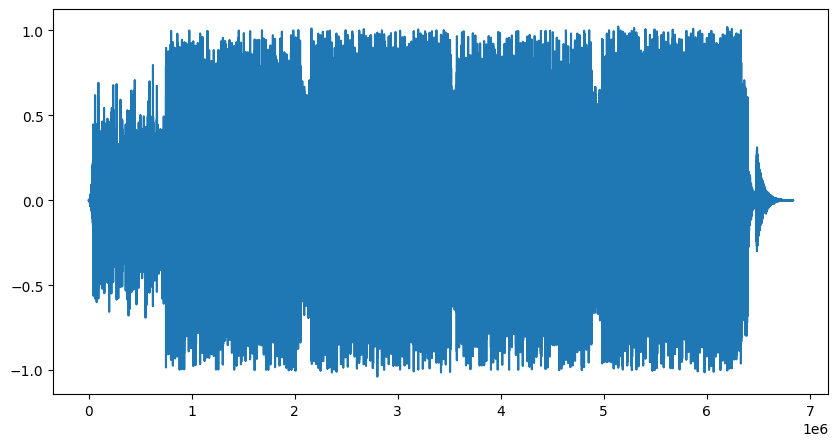

In [108]:
pd.Series(y).plot(figsize=(10,5))

In [109]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D),ref=np.max)
S_db.shape


(1025, 13354)

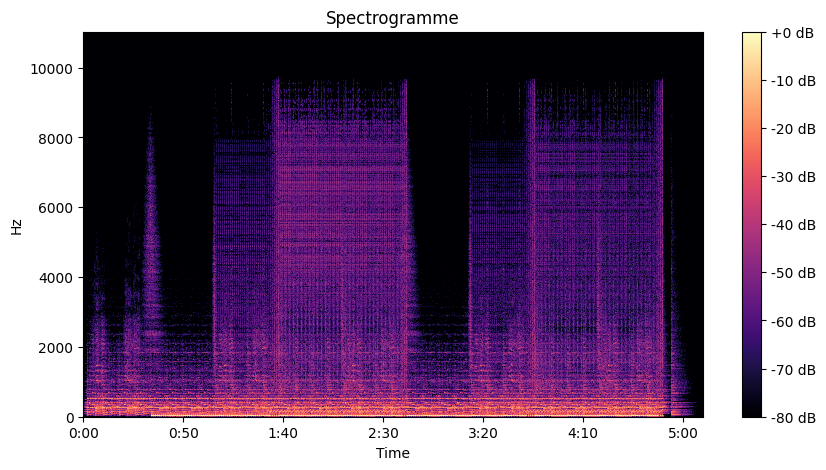

In [110]:
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                               x_axis='time',   
                               y_axis='hz',     
                               ax=ax)

fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set_title("Spectrogramme")
plt.show()

In [111]:
def get_peaks(S_db, neighborhood_size=20):
    # Trouve les maxima locaux dans un voisinage
    local_max = maximum_filter(S_db, size=neighborhood_size) == S_db
    # Garde seulement les pics au dessus d'un seuil
    threshold = S_db.max() - 40  # 40 dB sous le max
    peaks = local_max & (S_db > threshold)
    return np.where(peaks)

c:\Users\TheoN\Desktop\Shazam\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


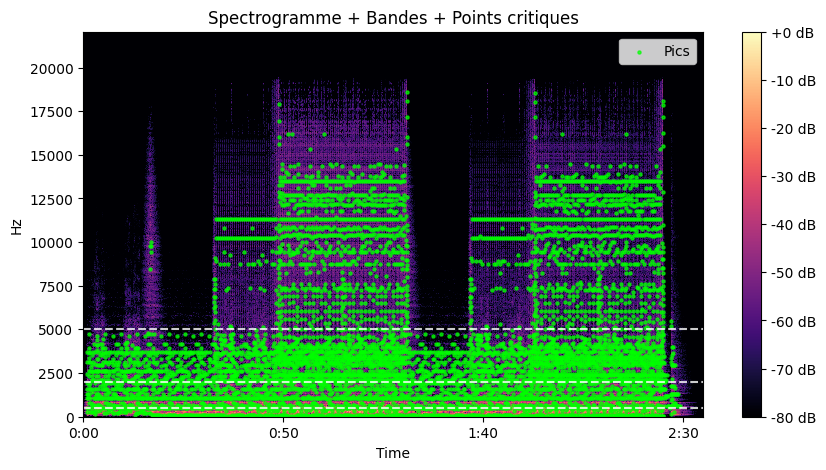

In [112]:
freq_peaks, time_peaks = get_peaks(S_db)

# Affichage
fig, ax = plt.subplots(figsize=(10, 5))

# Spectrogramme
img = librosa.display.specshow(S_db,
                               sr=sr,
                               x_axis='time',
                               y_axis='hz',
                               ax=ax)

# Traits verts pour les bandes de fréquences
bandes = [500, 2000, 5000]  # les séparations
for freq in bandes:
    ax.axhline(y=freq, color='white', linewidth=1.5, linestyle='--', alpha=0.8)

# Labels des bandes
#ax.text(0.5, 250,   "0–500 Hz",        color='lime', fontsize=8)
#ax.text(0.5, 1200,  "500–2000 Hz",     color='lime', fontsize=8)
#ax.text(0.5, 3500,  "2000–5000 Hz",    color='lime', fontsize=8)
#ax.text(0.5, 7000,  "5000–11000 Hz",   color='lime', fontsize=8)

ax.scatter(time_peaks * 512 / sr,
           freq_peaks * sr / 2048,
           color='lime', s=5, alpha=0.7, label='Pics')

fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.legend()
ax.set_title("Spectrogramme + Bandes + Points critiques")
plt.show()

In [113]:
def get_pairs(peaks, n_voisins=3):
    """
    peaks      : tuple retourné par get_peaks → (freq_peaks, time_peaks)
    n_voisins  : nombre de voisins à appairer par pic ancre
    
    return     : liste de tuples (i, j) représentant les indices des paires
    """
    freq_peaks, time_peaks = peaks
    
    times = time_peaks * 512 / sr
    freqs = freq_peaks * sr / 2048
    
    paires = []
    for i in range(len(times)):
        for j in range(1, n_voisins + 1):
            if i + j < len(times):
                delta_t = times[i + j] - times[i]
                if 0.5 < delta_t < 5:  # zone cible
                    paires.append((i, i + j))
    
    return paires

In [114]:
peaks = get_peaks(S_db)
paires = get_pairs(peaks, n_voisins=3)

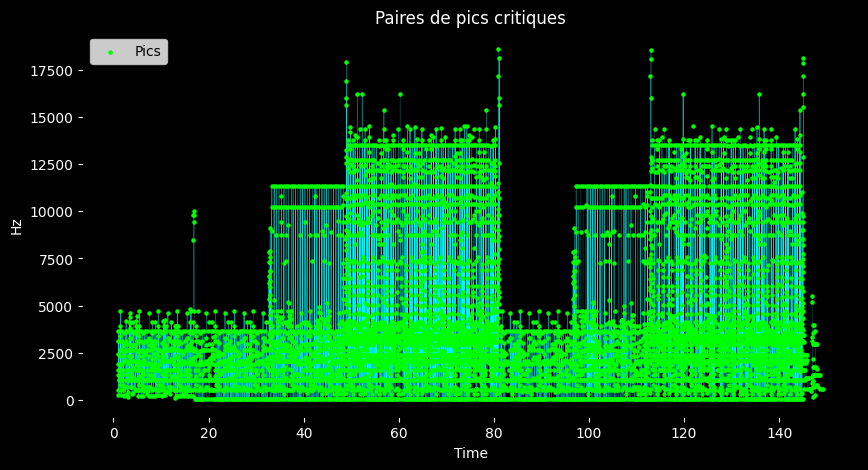

In [115]:
freq_peaks, time_peaks = peaks

times = time_peaks * 512 / sr
freqs = freq_peaks * sr / 2048

# Trier par temps
ordre = np.argsort(times)
times = times[ordre]
freqs = freqs[ordre]

fig, ax = plt.subplots(figsize=(10, 5))

for (i, j) in paires:
    ax.plot([times[i], times[j]],
            [freqs[i], freqs[j]],
            color='cyan', alpha=0.3, linewidth=0.5)

ax.scatter(times, freqs, color='lime', s=5, zorder=5, label='Pics')

ax.set_xlabel("Time")
ax.set_ylabel("Hz")
ax.set_title("Paires de pics critiques")
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.legend()
plt.show()

In [116]:
def get_hashes(peaks, paires):
    """
    peaks  : tuple retourné par get_peaks → (freq_peaks, time_peaks)
    paires : liste de tuples (i, j) retournée par get_pairs
    
    return : liste de tuples ((f1, f2, delta_t), t1)
    """
    freq_peaks, time_peaks = peaks

    times = time_peaks * 512 / sr
    freqs = freq_peaks * sr / 2048

    # Trier par temps
    ordre = np.argsort(times)
    times = times[ordre]
    freqs = freqs[ordre]

    hashes = []
    for (i, j) in paires:
        f1 = round(freqs[i] / 100) * 100      # arrondi à 100 Hz
        f2 = round(freqs[j] / 100) * 100      # arrondi à 100 Hz
        delta_t = round((times[j] - times[i]) * 10)  # arrondi à 0.1s
        t1 = times[i]                          # temps absolu de l'ancre

        hashes.append(((f1, f2, delta_t), t1))

    return hashes


In [118]:
print(f"Nombre de pics : {len(time_peaks)}")
print(f"Nombre de paires : {len(paires)}")
print(f"Nombre de hashes : {len(hashes)}")
print("Exemple :", hashes[0])

Nombre de pics : 7228
Nombre de paires : 11489
Nombre de hashes : 286
Exemple : ('8287473c036202c510c56c890bc0445d', np.float64(0.4179591836734694))


In [119]:
print(hashes)

[('8287473c036202c510c56c890bc0445d', np.float64(0.4179591836734694)), ('031879c0023559e908468f826cca3de9', np.float64(0.4179591836734694)), ('c41c22387095e7e0aa0cfd66c59e42e4', np.float64(0.44117913832199546)), ('ff79e875fa252195d6b65cf234ad8f39', np.float64(0.615328798185941)), ('f2f4297d6213c7d99572191187587d47', np.float64(0.615328798185941)), ('a02c3ea7eb7597197a386b0128456b00', np.float64(0.6617687074829932)), ('e783e573d0e39b81ed7aa1560344bb98', np.float64(0.7314285714285714)), ('d6f8382b566d82d0bb751a32d07bcc13', np.float64(0.9287981859410431)), ('3840e73ec15dc351548696e6c5cce722', np.float64(0.9287981859410431)), ('06807263ae042b4771c3709a78eaa2cf', np.float64(0.9520181405895691)), ('1f268322ecc4b6f8b2ca2e0f3c0ee332', np.float64(0.9520181405895691)), ('a4d00b5bc2fcfdee98e2e19146063ca7', np.float64(0.9520181405895691)), ('9d51cd02fb6fe8411cc442f696a31752', np.float64(0.9636281179138322)), ('c1f96f34c5011b49fde3b79d972f1133', np.float64(0.9636281179138322)), ('382e1eebad56b7794b

In [120]:
def get_hashes(peaks, paires):
    """
    peaks  : tuple retourné par get_peaks → (freq_peaks, time_peaks)
    paires : liste de tuples (i, j) retournée par get_pairs
    
    return : liste de tuples (hash_value, t1)
             hash_value : hash MD5 de la clé (f1, f2, delta_t)
             t1         : temps absolu du pic ancre en secondes
    """
    freq_peaks, time_peaks = peaks

    times = time_peaks * 512 / sr
    freqs = freq_peaks * sr / 2048

    ordre = np.argsort(times)
    times = times[ordre]
    freqs = freqs[ordre]

    hashes = []
    for (i, j) in paires:
        f1      = round(freqs[i] / 100) * 100
        f2      = round(freqs[j] / 100) * 100
        delta_t = round((times[j] - times[i]) * 10)
        t1      = times[i]

        cle         = f"{f1}|{f2}|{delta_t}"
        hash_value  = hashlib.md5(cle.encode()).hexdigest()

        hashes.append((hash_value, t1))

    return hashes

In [121]:
hashes = get_hashes(peaks, paires)
print(f"{len(hashes)} hashes générés")
print("Exemple :", hashes[0])

11489 hashes générés
Exemple : ('bf8fee0d3f2cd27fef0f25245e77ec17', np.float64(1.0332879818594105))
